In [9]:
# DEPENDENCIES
import pandas as pd
import numpy as np

import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Probit, Logit
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm

In [10]:
# LOAD DATA
data = pd.read_csv("diabetes.csv")

# PREPROCESSING: replace 0 → NaN
cols_zero_to_na = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols_zero_to_na:
    data[col] = data[col].replace(0, np.nan)
    data[col] = data[col].fillna(data[col].mean())

# DESCRIPTIVE STATISTICS
print(data.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.686763      72.405184      29.153420  155.548223   
std       3.369578   30.435949      12.096346       8.790942   85.021108   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.202592      29.153420  155.548223   
75%       6.000000  140.250000      80.000000      32.000000  155.548223   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.457464                  0.471876   33.240885    0.348958  
std      6.875151                  0.331329   11.760232    0.476951  
min     18.200000                  

In [11]:
print(data["Pregnancies"].describe())
print(data["Glucose"].describe())
print(data["Age"].describe())

count    768.000000
mean       3.845052
std        3.369578
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: Pregnancies, dtype: float64
count    768.000000
mean     121.686763
std       30.435949
min       44.000000
25%       99.750000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64
count    768.000000
mean      33.240885
std       11.760232
min       21.000000
25%       24.000000
50%       29.000000
75%       41.000000
max       81.000000
Name: Age, dtype: float64


In [12]:
# PROBIT MODEL
y = data["Outcome"]
X = data.drop(columns=["Outcome"])
X = sm.add_constant(X)

probit_model = Probit(y, X).fit()
print(probit_model.summary())

Optimization terminated successfully.
         Current function value: 0.463499
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  768
Model:                         Probit   Df Residuals:                      759
Method:                           MLE   Df Model:                            8
Date:                Wed, 10 Dec 2025   Pseudo R-squ.:                  0.2834
Time:                        14:47:45   Log-Likelihood:                -355.97
converged:                       True   LL-Null:                       -496.74
Covariance Type:            nonrobust   LLR p-value:                 3.458e-56
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -5.3534      0.448    -11.938      0.000      -6.232

In [13]:
# wald test: H0: BloodPressure = 0, Insulin = 0
R = np.zeros((2, len(probit_model.params)))
param_idx = list(probit_model.params.index)

R[0, param_idx.index("BloodPressure")] = 1
R[1, param_idx.index("Insulin")] = 1
r = np.zeros(2)

wald_stat = float((R @ probit_model.params - r).T @ 
                  np.linalg.inv(R @ probit_model.cov_params() @ R.T) @
                  (R @ probit_model.params - r))
p_value = 1 - chi2.cdf(wald_stat, df=2)
print("Wald test stat:", wald_stat, "p-value:", p_value)

Wald test stat: 1.7704663231914868 p-value: 0.4126179554014149


In [14]:
# Partial effects scalar
lin_pred = probit_model.predict(linear=True)
probit_scalar = np.mean(norm.pdf(lin_pred))   # ← ИСПРАВЛЕНО
partial_effects = probit_scalar * probit_model.params
print("Marginal effects:", partial_effects)

Marginal effects: const                      -1.388281
Pregnancies                 0.018718
Glucose                     0.005704
BloodPressure              -0.001384
SkinThickness               0.000690
Insulin                    -0.000148
BMI                         0.014289
DiabetesPedigreeFunction    0.114739
Age                         0.002177
dtype: float64


/Users/maria/Desktop/Code/.venv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:530: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


In [15]:
# Predictions
predict_prob = probit_model.predict()
pred_class = (predict_prob > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y, pred_class)
print("Confusion matrix:\n", cm)

Confusion matrix:
 [[443  57]
 [118 150]]


In [16]:
# Chi-square (manual analogue of chisq.test)
chi2_stat = (((cm - cm.mean())**2) / cm.mean()).sum()
print("Chi-square stat:", chi2_stat)

Chi-square stat: 460.76041666666663


AUC: 0.8439029850746269


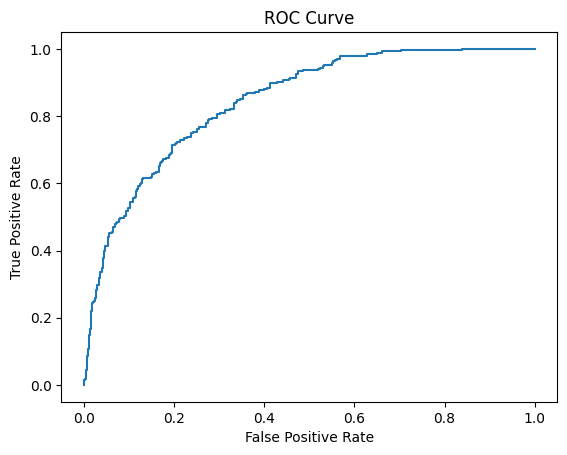

In [17]:
# ROC / AUC
auc = roc_auc_score(y, predict_prob)
print("AUC:", auc)

fpr, tpr, thr = roc_curve(y, predict_prob)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [18]:
# McFadden R2
ll_full = probit_model.llf
ll_null = Probit(y, sm.add_constant(pd.DataFrame({"const": np.ones(len(y))}))).fit().llf
mcfadden = 1 - ll_full / ll_null
print("McFadden R2:", mcfadden)


Optimization terminated successfully.
         Current function value: 0.646799
         Iterations 4
McFadden R2: 0.28339684212482064
